# Flight Disruption Risk Model
## Three-Season Holiday / Winter Operating Window Analysis

This project uses public BTS / DOT airline on-time performance data to evaluate flight disruption risk across three matched holiday/winter operating seasons:

- **2023–2024:** November 2023, December 2023, January 2024
- **2024–2025:** November 2024, December 2024, January 2025
- **2025–2026:** November 2025, December 2025, January 2026

The scope is deliberately controlled. The analysis does not try to model every month of airline operations. It isolates the same November–January operating window across three seasons so that holiday timing, winter exposure, and seasonal recovery pressure can be compared on a like-for-like basis.

Core question:

> Across matched November–January operating windows, do scheduled flight characteristics, holiday-period context, and departure-time patterns identify higher-risk flights and operating windows before disruption is realized?

The output should be read as an **operations prioritization screen**. It is designed to rank risk and support monitoring or extra on-call coverage decisions, not to automate staffing or produce calibrated disruption probabilities.


## 1. Setup

Place the nine BTS monthly CSV files in `data/raw/`. The combined analysis file is generated at the project root and is not intended for GitHub upload.

Expected file names:

```text
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_11.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_12.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_12.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv
```

The notebook combines them into:

```text
bts_on_time_performance_3season_nov_jan.csv
```

In [1]:
from pathlib import Path
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

COMBINED_FILE = Path("bts_on_time_performance_3season_nov_jan.csv")
REBUILD_COMBINED = False  # Set to True if you want to force a rebuild from the nine monthly CSVs.

RANDOM_STATE = 42
MODEL_SAMPLE_N = 300_000
TRAIN_SAMPLE_N = 300_000
MIN_TIME_BLOCK_FLIGHTS = 500
MIN_STAFFING_WINDOW_FLIGHTS = 25

PERIOD_ORDER = [
    "Thanksgiving Week",
    "Christmas Week",
    "New Year's Week",
    "Jan 15-30 Baseline",
]

SEASON_ORDER = ["2023-2024", "2024-2025", "2025-2026"]


In [2]:
def add_bar_labels(ax, fmt="{:.2f}", padding=0.01):
    """Add numeric labels above bars in a matplotlib bar chart."""
    y_min, y_max = ax.get_ylim()
    if y_max <= 0:
        return
    offset = (y_max - y_min) * padding
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if pd.isna(height):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + offset,
                fmt.format(height),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    ax.set_ylim(y_min, y_max * 1.12)


def safe_one_hot_encoder():
    """Return a OneHotEncoder that works across newer and older scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def pct_cols(data, cols):
    out = data.copy()
    for col in cols:
        if col in out.columns:
            out[col] = out[col] * 100
    return out


def display_export(data, filename, index=False):
    path = OUTPUT_DIR / filename
    data.to_csv(path, index=index)
    print(f"Saved {path}")
    return data


## 2. Data Import Map

The input list follows the BTS monthly file naming pattern and expands the analysis to nine files across three matched operating seasons.

The season label is based on the operating season, not calendar year alone:

- November/December 2023 + January 2024 = **2023-2024**
- November/December 2024 + January 2025 = **2024-2025**
- November/December 2025 + January 2026 = **2025-2026**


In [3]:
IMPORT_MAP = [
    {
        "season": "2023-2024",
        "year": 2023,
        "month": 11,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_11.csv",
    },
    {
        "season": "2023-2024",
        "year": 2023,
        "month": 12,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_12.csv",
    },
    {
        "season": "2023-2024",
        "year": 2024,
        "month": 1,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv",
    },
    {
        "season": "2024-2025",
        "year": 2024,
        "month": 11,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv",
    },
    {
        "season": "2024-2025",
        "year": 2024,
        "month": 12,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_12.csv",
    },
    {
        "season": "2024-2025",
        "year": 2025,
        "month": 1,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv",
    },
    {
        "season": "2025-2026",
        "year": 2025,
        "month": 11,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv",
    },
    {
        "season": "2025-2026",
        "year": 2025,
        "month": 12,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv",
    },
    {
        "season": "2025-2026",
        "year": 2026,
        "month": 1,
        "file": "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv",
    },
]

import_manifest = pd.DataFrame(IMPORT_MAP)
import_manifest["path"] = import_manifest["file"].apply(lambda f: str(DATA_DIR / f))
import_manifest["exists"] = import_manifest["file"].apply(lambda f: (DATA_DIR / f).exists())
import_manifest


,season,year,month,file,path,exists
0,2023-2024,2023,11,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
1,2023-2024,2023,12,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
2,2023-2024,2024,1,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
3,2024-2025,2024,11,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
4,2024-2025,2024,12,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
5,2024-2025,2025,1,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
6,2025-2026,2025,11,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
7,2025-2026,2025,12,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True
8,2025-2026,2026,1,On_Time_Reporting_Carrier_On_Time_Performance_...,data\raw\On_Time_Reporting_Carrier_On_Time_Per...,True


In [4]:
missing_files = import_manifest.loc[~import_manifest["exists"], "file"].tolist()
if missing_files:
    print("Missing files. Put these in the notebook folder before running the full analysis:")
    for file in missing_files:
        print(" -", file)
    raise FileNotFoundError(f"Missing {len(missing_files)} expected BTS CSV files.")
else:
    print("All nine expected BTS files are present.")


All nine expected BTS files are present.


## 3. Combine Monthly BTS Files

This import step only reads the columns needed for the analysis instead of pulling the full BTS file into memory. That keeps the three-season notebook more stable and faster than loading every raw BTS column.

The notebook preserves source lineage through:

- `source_file`
- `expected_season`
- `expected_year`
- `expected_month`

In [5]:
REQUIRED_COLUMNS = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
    "ArrDel15",
    "Cancelled",
    "Diverted",
]

OPTIONAL_COLUMNS = [
    "ArrDelay",
    "DepDelay",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

READ_COLUMNS = REQUIRED_COLUMNS + OPTIONAL_COLUMNS
READ_CHUNKSIZE = 75_000


def get_available_bts_columns(path, read_columns):
    """Read only the header and return required analysis columns available in the BTS file."""
    header = pd.read_csv(path, nrows=0).columns
    header = [c for c in header if not str(c).startswith("Unnamed:")]
    usecols = [c for c in read_columns if c in header]

    missing_required = [c for c in REQUIRED_COLUMNS if c not in usecols]
    if missing_required:
        raise ValueError(f"{path.name} is missing required columns: {missing_required}")

    return usecols


def iter_bts_month_chunks(path, meta, read_columns, chunksize=READ_CHUNKSIZE):
    """
    Stream a BTS monthly CSV in chunks.

    This avoids loading a 200MB+ raw BTS file into memory at once. The BTS files may
    contain many columns, but the analysis only needs READ_COLUMNS plus source metadata.
    """
    usecols = get_available_bts_columns(path, read_columns)

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        chunksize=chunksize,
        low_memory=True,
        dtype={col: "string" for col in usecols},
    ):
        chunk = chunk.loc[:, ~chunk.columns.duplicated()].copy()
        chunk["source_file"] = meta["file"]
        chunk["expected_season"] = meta["season"]
        chunk["expected_year"] = meta["year"]
        chunk["expected_month"] = meta["month"]
        yield chunk


def combined_file_has_expected_sources(path, expected_files, chunksize=250_000):
    """Check source-file coverage without reading the full combined file into memory."""
    if not path.exists():
        return False
    try:
        seen = set()
        for chunk in pd.read_csv(path, usecols=["source_file"], chunksize=chunksize, low_memory=True):
            seen.update(chunk["source_file"].dropna().unique().tolist())
            if seen == set(expected_files):
                return True
        return seen == set(expected_files)
    except Exception:
        return False


expected_files = [m["file"] for m in IMPORT_MAP]
should_build = REBUILD_COMBINED or not combined_file_has_expected_sources(COMBINED_FILE, expected_files)

if should_build:
    if COMBINED_FILE.exists():
        COMBINED_FILE.unlink()

    total_rows = 0
    total_chunks = 0
    wrote_header = False

    for meta in IMPORT_MAP:
        path = DATA_DIR / meta["file"]
        print(f"Loading {path} in chunks...")
        month_rows = 0

        for chunk in iter_bts_month_chunks(path, meta, READ_COLUMNS):
            chunk.to_csv(COMBINED_FILE, mode="a", index=False, header=not wrote_header)
            wrote_header = True
            month_rows += len(chunk)
            total_rows += len(chunk)
            total_chunks += 1

        print(f"  rows={month_rows:,}")

    print(f"Saved {COMBINED_FILE}")
    print(f"Combined rows written: {total_rows:,}")
    print(f"Chunks written: {total_chunks:,}")
else:
    print(f"{COMBINED_FILE} already exists and contains the expected source files.")



Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_11.csv in chunks...


  rows=563,777
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_12.csv in chunks...


  rows=570,394
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv in chunks...


  rows=547,271
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv in chunks...


  rows=575,404
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_12.csv in chunks...


  rows=590,581
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv in chunks...


  rows=539,747
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv in chunks...


  rows=570,550
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv in chunks...


  rows=582,304
Loading data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv in chunks...


  rows=544,003
Saved bts_on_time_performance_3season_nov_jan.csv
Combined rows written: 5,084,031
Chunks written: 72


## 4. Load and Validate Combined Data

This section confirms that the combined file contains the expected three-season structure before any analysis or modeling happens.

In [6]:
df = pd.read_csv(COMBINED_FILE, low_memory=True)
df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed:")], errors="ignore")
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Shape:", df.shape)
df.head()



Shape: (5084031, 30)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepDelay,DepTimeBlk,CRSArrTime,ArrDelay,ArrDel15,ArrTimeBlk,Cancelled,Diverted,CRSElapsedTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,source_file,expected_season,expected_year,expected_month
0,2023,4,11,1,3,2023-11-01,9E,DSM,LGA,1406,-3.0000,1400-1459,1748,-21.0000,0.0000,1700-1759,0.0000,0.0000,162.0000,"1,031.0000",5,NaN,NaN,NaN,NaN,NaN,On_Time_Reporting_Carrier_On_Time_Performance_...,2023-2024,2023,11
1,2023,4,11,2,4,2023-11-02,9E,DSM,LGA,1406,3.0000,1400-1459,1748,-4.0000,0.0000,1700-1759,0.0000,0.0000,162.0000,"1,031.0000",5,NaN,NaN,NaN,NaN,NaN,On_Time_Reporting_Carrier_On_Time_Performance_...,2023-2024,2023,11
2,2023,4,11,3,5,2023-11-03,9E,DSM,LGA,1406,-5.0000,1400-1459,1748,-21.0000,0.0000,1700-1759,0.0000,0.0000,162.0000,"1,031.0000",5,NaN,NaN,NaN,NaN,NaN,On_Time_Reporting_Carrier_On_Time_Performance_...,2023-2024,2023,11
3,2023,4,11,5,7,2023-11-05,9E,LGA,STL,1848,5.0000,1800-1859,2048,0.0000,0.0000,2000-2059,0.0000,0.0000,180.0000,888.0000,4,NaN,NaN,NaN,NaN,NaN,On_Time_Reporting_Carrier_On_Time_Performance_...,2023-2024,2023,11
4,2023,4,11,6,1,2023-11-06,9E,LGA,STL,1846,-8.0000,1800-1859,2046,-11.0000,0.0000,2000-2059,0.0000,0.0000,180.0000,888.0000,4,NaN,NaN,NaN,NaN,NaN,On_Time_Reporting_Carrier_On_Time_Performance_...,2023-2024,2023,11


In [7]:
missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns after load: {missing}")

print("All required fields are present.")

file_row_counts = (
    df.groupby(["expected_season", "expected_year", "expected_month", "source_file"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["expected_season", "expected_year", "expected_month"])
)

file_row_counts


All required fields are present.


,expected_season,expected_year,expected_month,source_file,rows
0,2023-2024,2023,11,On_Time_Reporting_Carrier_On_Time_Performance_...,563777
1,2023-2024,2023,12,On_Time_Reporting_Carrier_On_Time_Performance_...,570394
2,2023-2024,2024,1,On_Time_Reporting_Carrier_On_Time_Performance_...,547271
3,2024-2025,2024,11,On_Time_Reporting_Carrier_On_Time_Performance_...,575404
4,2024-2025,2024,12,On_Time_Reporting_Carrier_On_Time_Performance_...,590581
5,2024-2025,2025,1,On_Time_Reporting_Carrier_On_Time_Performance_...,539747
6,2025-2026,2025,11,On_Time_Reporting_Carrier_On_Time_Performance_...,570550
7,2025-2026,2025,12,On_Time_Reporting_Carrier_On_Time_Performance_...,582304
8,2025-2026,2026,1,On_Time_Reporting_Carrier_On_Time_Performance_...,544003


## 5. Target Construction

A flight is labeled as disrupted if it experienced at least one of the following outcomes:

```text
disrupted = 1 if ArrDel15 == 1 OR Cancelled == 1 OR Diverted == 1
```

This remains broader than a pure delay model and better aligned with operations because arrival delays, cancellations, and diversions all create customer-impact or operational recovery work.

In [8]:
NUMERIC_COLS = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
    "ArrDel15",
    "Cancelled",
    "Diverted",
    "ArrDelay",
    "DepDelay",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")

df["disrupted"] = (
    (df["ArrDel15"].fillna(0) == 1)
    | (df["Cancelled"].fillna(0) == 1)
    | (df["Diverted"].fillna(0) == 1)
).astype(int)

df["delay15_flag"] = (df["ArrDel15"].fillna(0) == 1).astype(int)
df["cancel_flag"] = (df["Cancelled"].fillna(0) == 1).astype(int)
df["divert_flag"] = (df["Diverted"].fillna(0) == 1).astype(int)

# Season from actual Year/Month, used as a validation check against expected file season.
df["season"] = np.where(
    df["Month"].isin([11, 12]),
    df["Year"].astype("Int64").astype(str) + "-" + (df["Year"] + 1).astype("Int64").astype(str),
    np.where(
        df["Month"].eq(1),
        (df["Year"] - 1).astype("Int64").astype(str) + "-" + df["Year"].astype("Int64").astype(str),
        pd.NA,
    ),
)

df["season_start_year"] = df["season"].str.slice(0, 4).astype("Int64")

season_check = (
    df.groupby(["expected_season", "season"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["expected_season", "season"])
)

season_check


,expected_season,season,rows
0,2023-2024,2023-2024,1681442
1,2024-2025,2024-2025,1705732
2,2025-2026,2025-2026,1696857


In [9]:
if not (df["expected_season"].astype(str) == df["season"].astype(str)).all():
    bad = df.loc[df["expected_season"].astype(str) != df["season"].astype(str), ["source_file", "FlightDate", "Year", "Month", "expected_season", "season"]].head(20)
    raise ValueError(f"Some rows do not match expected season labels. Example rows:\n{bad}")

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Seasons",
        "Source files",
        "Disruption rate",
        "Arrival delay 15+ rate",
        "Cancellation rate",
        "Diversion rate",
        "Airlines",
        "Origin airports",
        "Destination airports",
    ],
    "Value": [
        f"{len(df):,}",
        df.shape[1],
        df["season"].nunique(),
        df["source_file"].nunique(),
        f"{df['disrupted'].mean():.2%}",
        f"{df['delay15_flag'].mean():.2%}",
        f"{df['cancel_flag'].mean():.2%}",
        f"{df['divert_flag'].mean():.2%}",
        df["Reporting_Airline"].nunique(),
        df["Origin"].nunique(),
        df["Dest"].nunique(),
    ]
})

summary


,Metric,Value
0,Rows,"5,084,031"
1,Columns,36
2,Seasons,3
3,Source files,9
4,Disruption rate,21.21%
5,Arrival delay 15+ rate,19.13%
6,Cancellation rate,1.88%
7,Diversion rate,0.20%
8,Airlines,15
9,Origin airports,351


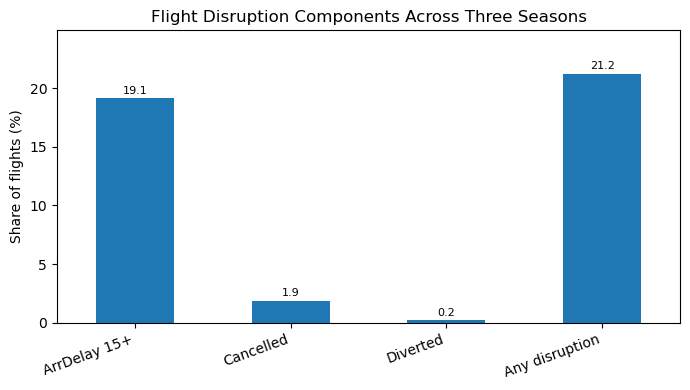

In [10]:
components = pd.Series({
    "ArrDelay 15+": df["delay15_flag"].mean() * 100,
    "Cancelled": df["cancel_flag"].mean() * 100,
    "Diverted": df["divert_flag"].mean() * 100,
    "Any disruption": df["disrupted"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(7, 4))
components.plot(kind="bar", ax=ax)
ax.set_title("Flight Disruption Components Across Three Seasons")
ax.set_ylabel("Share of flights (%)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
add_bar_labels(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()


## 6. Season-Aware Holiday and Baseline Windows

This section converts calendar dates into comparable operating windows for each season.

Each season receives the same four analytical windows:

- **Thanksgiving Week:** Sunday before Thanksgiving through Sunday after Thanksgiving
- **Christmas Week:** December 21 through December 28
- **New Year's Week:** December 29 through January 4
- **Jan 15-30 Baseline:** January 15 through January 30

This structure keeps the analysis narrow while allowing direct cross-season comparison. It avoids mixing unrelated months into the model and keeps the operational question centered on holiday/winter staffing pressure.


In [11]:
def thanksgiving_date(year):
    """Return Thanksgiving date for a U.S. calendar year: fourth Thursday in November."""
    cal = calendar.Calendar(firstweekday=calendar.SUNDAY)
    thursdays = [
        day
        for week in cal.monthdatescalendar(year, 11)
        for day in week
        if day.month == 11 and day.weekday() == calendar.THURSDAY
    ]
    return pd.Timestamp(thursdays[3])


def build_period_windows(season_start_years):
    rows = []
    for start_year in season_start_years:
        season = f"{start_year}-{start_year + 1}"
        tg = thanksgiving_date(start_year)
        rows.append({
            "season": season,
            "analysis_period": "Thanksgiving Week",
            "start": tg - pd.Timedelta(days=4),
            "end": tg + pd.Timedelta(days=3),
            "period_sort": 1,
        })
        rows.append({
            "season": season,
            "analysis_period": "Christmas Week",
            "start": pd.Timestamp(start_year, 12, 21),
            "end": pd.Timestamp(start_year, 12, 28),
            "period_sort": 2,
        })
        rows.append({
            "season": season,
            "analysis_period": "New Year's Week",
            "start": pd.Timestamp(start_year, 12, 29),
            "end": pd.Timestamp(start_year + 1, 1, 4),
            "period_sort": 3,
        })
        rows.append({
            "season": season,
            "analysis_period": "Jan 15-30 Baseline",
            "start": pd.Timestamp(start_year + 1, 1, 15),
            "end": pd.Timestamp(start_year + 1, 1, 30),
            "period_sort": 4,
        })
    return pd.DataFrame(rows)


period_windows = build_period_windows([2023, 2024, 2025])
period_windows["window_label"] = period_windows["start"].dt.strftime("%Y-%m-%d") + " to " + period_windows["end"].dt.strftime("%Y-%m-%d")
period_windows.sort_values(["season", "period_sort"])


,season,analysis_period,start,end,period_sort,window_label
0,2023-2024,Thanksgiving Week,2023-11-19,2023-11-26,1,2023-11-19 to 2023-11-26
1,2023-2024,Christmas Week,2023-12-21,2023-12-28,2,2023-12-21 to 2023-12-28
2,2023-2024,New Year's Week,2023-12-29,2024-01-04,3,2023-12-29 to 2024-01-04
3,2023-2024,Jan 15-30 Baseline,2024-01-15,2024-01-30,4,2024-01-15 to 2024-01-30
4,2024-2025,Thanksgiving Week,2024-11-24,2024-12-01,1,2024-11-24 to 2024-12-01
5,2024-2025,Christmas Week,2024-12-21,2024-12-28,2,2024-12-21 to 2024-12-28
6,2024-2025,New Year's Week,2024-12-29,2025-01-04,3,2024-12-29 to 2025-01-04
7,2024-2025,Jan 15-30 Baseline,2025-01-15,2025-01-30,4,2025-01-15 to 2025-01-30
8,2025-2026,Thanksgiving Week,2025-11-23,2025-11-30,1,2025-11-23 to 2025-11-30
9,2025-2026,Christmas Week,2025-12-21,2025-12-28,2,2025-12-21 to 2025-12-28


In [12]:
df["analysis_period"] = "Other"
df["period_start"] = pd.NaT
df["period_end"] = pd.NaT

for row in period_windows.itertuples(index=False):
    mask = (
        df["season"].eq(row.season)
        & df["FlightDate"].between(row.start, row.end, inclusive="both")
    )
    df.loc[mask, "analysis_period"] = row.analysis_period
    df.loc[mask, "period_start"] = row.start
    df.loc[mask, "period_end"] = row.end

df["period_day"] = (df["FlightDate"] - df["period_start"]).dt.days

holiday_df = df[df["analysis_period"].isin(PERIOD_ORDER)].copy()
holiday_df["analysis_period"] = pd.Categorical(holiday_df["analysis_period"], categories=PERIOD_ORDER, ordered=True)
holiday_df["season"] = pd.Categorical(holiday_df["season"], categories=SEASON_ORDER, ordered=True)

holiday_counts = (
    holiday_df.groupby(["season", "analysis_period"], observed=False)
    .size()
    .reset_index(name="flights")
)

holiday_counts


,season,analysis_period,flights
0,2023-2024,Thanksgiving Week,147556
1,2023-2024,Christmas Week,148162
2,2023-2024,New Year's Week,127367
3,2023-2024,Jan 15-30 Baseline,281684
4,2024-2025,Thanksgiving Week,155808
5,2024-2025,Christmas Week,151518
6,2024-2025,New Year's Week,131488
7,2024-2025,Jan 15-30 Baseline,273873
8,2025-2026,Thanksgiving Week,153460
9,2025-2026,Christmas Week,150206


### Window-volume validation

The defined holiday/baseline windows have reasonable flight volume across all three seasons. The January baseline has more flights because it spans January 15–30, while the holiday windows are shorter. That difference is expected and should be considered when comparing raw flight counts. The rate-based metrics are the primary comparison point.


## 7. Holiday/Baseline Performance by Season

This section compares the four defined operating windows across all three seasons.

The important change is that the analysis can now distinguish:

- recurring holiday/winter patterns, and
- one-year disruptions or abnormal event spikes.

In [13]:
agg_dict = {
    "flights": ("disrupted", "size"),
    "disruption_rate": ("disrupted", "mean"),
    "delay15_rate": ("delay15_flag", "mean"),
    "cancellation_rate": ("cancel_flag", "mean"),
    "diversion_rate": ("divert_flag", "mean"),
}

if "ArrDelay" in holiday_df.columns:
    agg_dict["avg_arr_delay"] = ("ArrDelay", "mean")
    agg_dict["median_arr_delay"] = ("ArrDelay", "median")

period_summary_by_season = (
    holiday_df.groupby(["season", "analysis_period"], observed=False)
    .agg(**agg_dict)
    .reset_index()
)

rate_cols = ["disruption_rate", "delay15_rate", "cancellation_rate", "diversion_rate"]
period_summary_by_season = pct_cols(period_summary_by_season, rate_cols)
period_summary_by_season = period_summary_by_season.sort_values(["season", "analysis_period"])

display_export(period_summary_by_season, "period_summary_by_season.csv")


Saved outputs\period_summary_by_season.csv


,season,analysis_period,flights,disruption_rate,delay15_rate,cancellation_rate,diversion_rate,avg_arr_delay,median_arr_delay
0,2023-2024,Thanksgiving Week,147556,17.2667,17.0179,0.1308,0.1179,1.4307,-8.0000
1,2023-2024,Christmas Week,148162,21.0769,20.0470,0.7728,0.2572,4.5663,-6.0000
2,2023-2024,New Year's Week,127367,15.5668,15.2967,0.1649,0.1052,-1.0021,-8.0000
3,2023-2024,Jan 15-30 Baseline,281684,27.2294,22.7631,4.2171,0.2492,10.5847,-5.0000
4,2024-2025,Thanksgiving Week,155808,16.6859,16.4414,0.1483,0.0963,1.5679,-8.0000
5,2024-2025,Christmas Week,151518,27.2568,25.8161,1.1127,0.3280,13.1153,-4.0000
6,2024-2025,New Year's Week,131488,24.5133,23.4166,0.7202,0.3765,9.0298,-5.0000
7,2024-2025,Jan 15-30 Baseline,273873,16.9611,14.6046,2.1773,0.1793,-0.8567,-10.0000
8,2025-2026,Thanksgiving Week,153460,25.0782,22.9141,1.9288,0.2352,10.1790,-6.0000
9,2025-2026,Christmas Week,150206,27.7805,25.3365,2.1590,0.2849,11.2833,-4.0000


In [14]:
period_summary_all_seasons = (
    holiday_df.groupby("analysis_period", observed=False)
    .agg(**agg_dict)
    .reindex(PERIOD_ORDER)
    .reset_index()
)
period_summary_all_seasons = pct_cols(period_summary_all_seasons, rate_cols)

display_export(period_summary_all_seasons, "period_summary_all_seasons.csv")


Saved outputs\period_summary_all_seasons.csv


,analysis_period,flights,disruption_rate,delay15_rate,cancellation_rate,diversion_rate,avg_arr_delay,median_arr_delay
0,Thanksgiving Week,456824,19.6927,18.8020,0.7408,0.1499,4.3788,-7.0000
1,Christmas Week,449886,25.3964,23.7560,1.3501,0.2903,9.6757,-5.0000
2,New Year's Week,391940,23.8738,22.7298,0.8932,0.2508,7.7953,-5.0000
3,Jan 15-30 Baseline,834721,24.3171,19.3744,4.7397,0.2031,6.3930,-7.0000


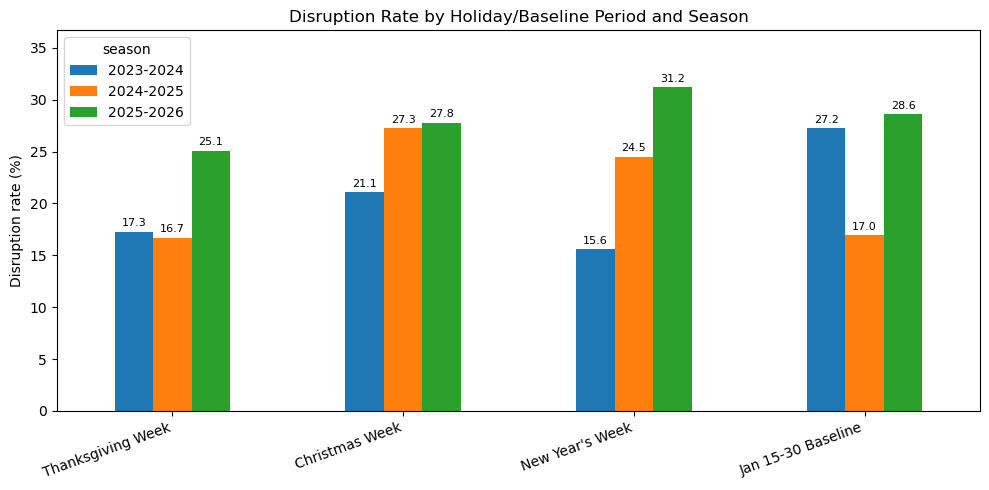

season,2023-2024,2024-2025,2025-2026
analysis_period,,,
Thanksgiving Week,17.2667,16.6859,25.0782
Christmas Week,21.0769,27.2568,27.7805
New Year's Week,15.5668,24.5133,31.1921
Jan 15-30 Baseline,27.2294,16.9611,28.5950


In [15]:
period_pivot = period_summary_by_season.pivot(index="analysis_period", columns="season", values="disruption_rate").reindex(PERIOD_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
period_pivot.plot(kind="bar", ax=ax)
ax.set_title("Disruption Rate by Holiday/Baseline Period and Season")
ax.set_ylabel("Disruption rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
add_bar_labels(ax, fmt="{:.1f}", padding=0.01)
plt.tight_layout()
plt.show()

period_pivot


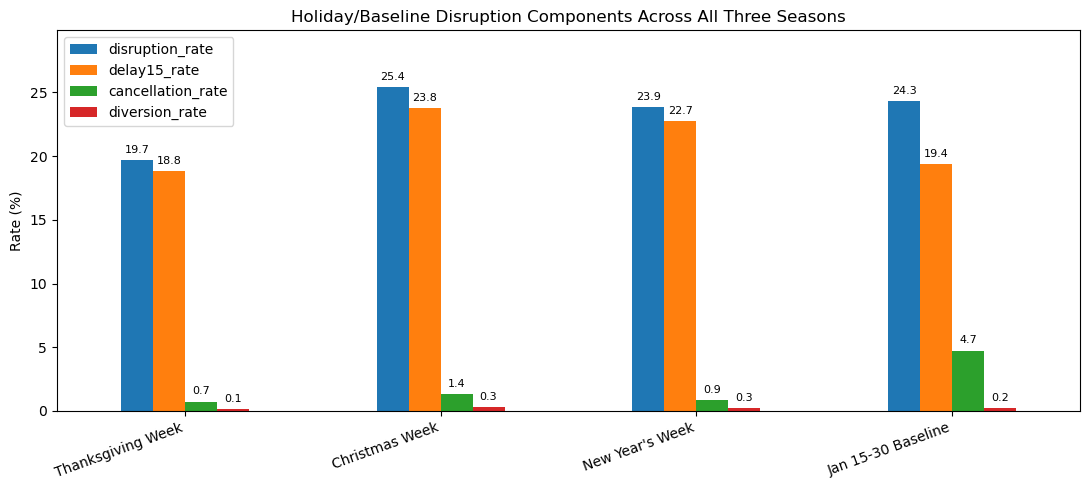

,disruption_rate,delay15_rate,cancellation_rate,diversion_rate
analysis_period,,,,
Thanksgiving Week,19.6927,18.8020,0.7408,0.1499
Christmas Week,25.3964,23.7560,1.3501,0.2903
New Year's Week,23.8738,22.7298,0.8932,0.2508
Jan 15-30 Baseline,24.3171,19.3744,4.7397,0.2031


In [16]:
period_components_all = period_summary_all_seasons.set_index("analysis_period")[[
    "disruption_rate",
    "delay15_rate",
    "cancellation_rate",
    "diversion_rate",
]]

fig, ax = plt.subplots(figsize=(11, 5))
period_components_all.plot(kind="bar", ax=ax)
ax.set_title("Holiday/Baseline Disruption Components Across All Three Seasons")
ax.set_ylabel("Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
add_bar_labels(ax, fmt="{:.1f}", padding=0.015)
plt.tight_layout()
plt.show()

period_components_all


### Holiday/baseline performance interpretation

Across all three seasons, **Christmas Week was the highest-risk window overall**, with a disruption rate of about **25.4%**. The **January 15–30 baseline** was close behind at about **24.3%**, followed by **New Year's Week** at about **23.9%** and **Thanksgiving Week** at about **19.7%**.

The important finding is not just the ranking of periods; it is the **composition of disruption**. Christmas and New Year's risk was mostly delay-driven, while the January baseline carried a much larger cancellation load. Across all three seasons, the January baseline cancellation rate was about **4.7%**, versus about **1.4%** for Christmas Week and **0.9%** for New Year's Week.

The latest season, **2025–2026**, was a materially higher-disruption regime across several windows: Thanksgiving reached about **25.1%**, New Year's Week reached about **31.2%**, and the January baseline reached about **28.6%**. The three-season view therefore separates two ideas that would otherwise get blurred together: some holiday/winter pressure is recurring, but the latest season was still unusually elevated.

Operational implication: delay-heavy holiday windows support planned monitoring, connection-management, and customer-communication readiness. Cancellation-heavy January spikes require a different playbook: rebooking capacity, escalation coverage, and recovery coordination.


## 8. Daily Trend Analysis Inside the Holiday/Baseline Windows

The daily view separates sustained operating-period pressure from isolated event-driven spikes.

Rather than displaying multiple daily line charts, the final notebook surfaces the highest-disruption days as a compact table. That keeps the analysis focused on the operational question: which dates behaved like broad holiday pressure, and which looked like acute disruption events?


In [17]:
daily_summary = (
    holiday_df.groupby(
        ["season", "analysis_period", "FlightDate", "period_day"],
        observed=True,
    )
    .agg(
        flights=("disrupted", "size"),
        disruption_rate=("disrupted", "mean"),
        delay15_rate=("delay15_flag", "mean"),
        cancellation_rate=("cancel_flag", "mean"),
        diversion_rate=("divert_flag", "mean"),
    )
    .reset_index()
)

daily_summary = daily_summary[daily_summary["flights"] > 0].copy()
daily_summary["period_day"] = daily_summary["period_day"].astype(int)
daily_summary = pct_cols(daily_summary, ["disruption_rate", "delay15_rate", "cancellation_rate", "diversion_rate"])
daily_summary = daily_summary.sort_values(["season", "analysis_period", "FlightDate"])

_ = display_export(daily_summary, "daily_summary_by_season.csv")
print(f"Daily summary rows exported: {len(daily_summary):,}")


Saved outputs\daily_summary_by_season.csv
Daily summary rows exported: 117


In [18]:
top_daily_spikes = (
    daily_summary.sort_values("disruption_rate", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display_export(top_daily_spikes, "top_daily_disruption_spikes.csv")


Saved outputs\top_daily_disruption_spikes.csv


,season,analysis_period,FlightDate,period_day,flights,disruption_rate,delay15_rate,cancellation_rate,diversion_rate
0,2025-2026,Jan 15-30 Baseline,2026-01-25,10,18675,69.7028,23.0522,46.4846,0.1660
1,2023-2024,Jan 15-30 Baseline,2024-01-15,0,18620,58.0290,41.6112,15.9076,0.5102
2,2023-2024,Jan 15-30 Baseline,2024-01-16,1,16530,57.7798,44.7973,12.7707,0.2117
3,2025-2026,Jan 15-30 Baseline,2026-01-26,11,18042,57.4770,30.1685,27.1201,0.1884
4,2025-2026,Thanksgiving Week,2025-11-30,7,21576,49.0452,44.9852,3.8515,0.2086
5,2025-2026,Christmas Week,2025-12-28,7,19999,42.5321,38.8319,3.3002,0.4000
6,2024-2025,New Year's Week,2024-12-29,0,20203,42.3353,40.2267,1.5641,0.5445
7,2025-2026,Jan 15-30 Baseline,2026-01-27,12,16191,41.5231,27.5338,13.8596,0.1297
8,2025-2026,Christmas Week,2025-12-27,6,19153,41.1058,36.6418,4.0829,0.3811
9,2023-2024,Jan 15-30 Baseline,2024-01-19,4,18698,40.6835,35.2551,5.2038,0.2246


### Daily spike interpretation

The daily spike table is more useful than a large set of daily line charts. It separates sustained holiday/winter pressure from isolated event-driven disruption days.

The largest spikes were concentrated in the January baseline and late-holiday return windows. The most severe example was **January 25, 2026**, when the disruption rate reached about **69.7%** and cancellations alone were about **46.5%**. January 15–16, 2024 also had disruption rates near **58%**, with a mix of high delay and cancellation activity.

Holiday return days still matter. Late Thanksgiving, Christmas, and New Year's dates appear in the spike list, but those days were generally more delay-driven than the worst January cancellation events. That distinction supports two different operating responses: planned holiday monitoring for sustained delay pressure, and rapid escalation capacity for acute cancellation-heavy days.


## 9. Scheduled Departure Time-Block Analysis

This section tests whether disruption risk increases later in the day and whether that pattern repeats across holiday/baseline windows.

Scheduled departure time is not treated as a causal variable. It is a practical proxy for accumulated network exposure: aircraft rotations, crew timing, gate constraints, airport congestion, and earlier delays can compound as the day progresses.


In [19]:
timeblock_summary = (
    holiday_df.groupby(["season", "analysis_period", "DepTimeBlk"], observed=True)
    .agg(
        flights=("disrupted", "size"),
        disruption_rate=("disrupted", "mean"),
        delay15_rate=("delay15_flag", "mean"),
        cancellation_rate=("cancel_flag", "mean"),
    )
    .reset_index()
)

timeblock_summary = timeblock_summary[timeblock_summary["flights"] >= MIN_TIME_BLOCK_FLIGHTS].copy()
timeblock_summary = pct_cols(timeblock_summary, ["disruption_rate", "delay15_rate", "cancellation_rate"])
timeblock_summary = timeblock_summary.sort_values(["season", "analysis_period", "DepTimeBlk"])

_ = display_export(timeblock_summary, "timeblock_summary_by_period.csv")
print(f"Time-block summary rows exported: {len(timeblock_summary):,}")


Saved outputs\timeblock_summary_by_period.csv
Time-block summary rows exported: 228


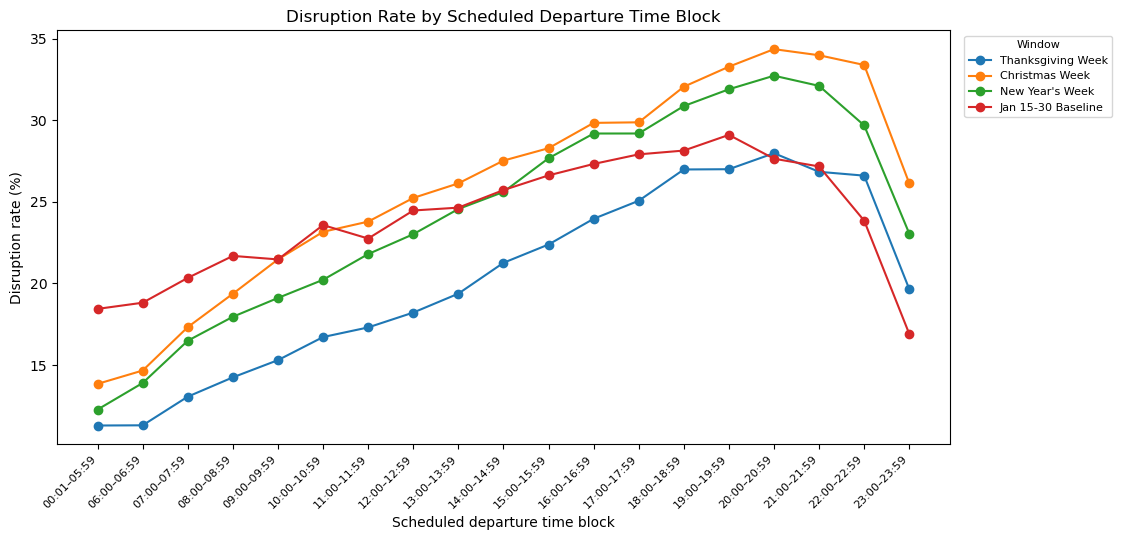

analysis_period,Thanksgiving Week,Christmas Week,New Year's Week,Jan 15-30 Baseline
DepTimeBlk,,,,
0001-0559,11.2907,13.8447,12.2710,18.4429
0600-0659,11.3031,14.6636,13.8998,18.8210
0700-0759,13.0612,17.3249,16.4907,20.3437
0800-0859,14.2446,19.3719,17.9589,21.6911
0900-0959,15.3004,21.4757,19.1127,21.4757
1000-1059,16.7154,23.1679,20.2261,23.5808
1100-1159,17.3058,23.7940,21.8033,22.7558
1200-1259,18.2163,25.2453,23.0207,24.4757
1300-1359,19.3765,26.1388,24.5670,24.6506


In [20]:
def format_time_block(block):
    """Convert BTS time blocks like '1800-1859' into readable labels like '18:00–18:59'."""
    if pd.isna(block):
        return "Unknown"

    text = str(block)
    if "-" not in text:
        return text

    start, end = text.split("-", 1)
    if len(start) == 4 and len(end) == 4 and start.isdigit() and end.isdigit():
        return f"{start[:2]}:{start[2:]}–{end[:2]}:{end[2:]}"

    return text


timeblock_all = (
    holiday_df.groupby(["analysis_period", "DepTimeBlk"], observed=True)
    .agg(
        flights=("disrupted", "size"),
        disruption_rate=("disrupted", "mean"),
    )
    .reset_index()
)

timeblock_all = timeblock_all[timeblock_all["flights"] >= MIN_TIME_BLOCK_FLIGHTS].copy()
timeblock_all["disruption_rate"] = timeblock_all["disruption_rate"] * 100

timeblock_pivot = (
    timeblock_all.pivot(index="DepTimeBlk", columns="analysis_period", values="disruption_rate")
    .reindex(columns=PERIOD_ORDER)
)

timeblock_pivot = timeblock_pivot.sort_index(
    key=lambda idx: idx.to_series().str.slice(0, 4).astype(int)
)

timeblock_labels = [format_time_block(block) for block in timeblock_pivot.index]

fig, ax = plt.subplots(figsize=(13.5, 5.5))
timeblock_pivot.plot(marker="o", ax=ax)

ax.set_title("Disruption Rate by Scheduled Departure Time Block")
ax.set_ylabel("Disruption rate (%)")
ax.set_xlabel("Scheduled departure time block")

ax.set_xticks(range(len(timeblock_pivot.index)))
ax.set_xticklabels(timeblock_labels, rotation=45, ha="right", fontsize=8)

ax.legend(
    title="Window",
    fontsize=8,
    title_fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

timeblock_pivot


In [21]:
late_blocks = ["1600-1659", "1700-1759", "1800-1859", "1900-1959", "2000-2059", "2100-2159", "2200-2259"]

late_day_summary = (
    timeblock_summary[timeblock_summary["DepTimeBlk"].isin(late_blocks)]
    .groupby(["season", "analysis_period"], observed=True)
    .apply(lambda g: pd.Series({
        "late_day_flights": g["flights"].sum(),
        "late_day_disruption_rate": np.average(g["disruption_rate"], weights=g["flights"]),
    }))
    .reset_index()
    .sort_values(["season", "analysis_period"])
)

display_export(late_day_summary, "late_day_summary_by_season_period.csv")


Saved outputs\late_day_summary_by_season_period.csv


,season,analysis_period,late_day_flights,late_day_disruption_rate
0,2023-2024,Thanksgiving Week,"49,006.0000",23.6114
1,2023-2024,Christmas Week,"50,522.0000",27.0041
2,2023-2024,New Year's Week,"43,201.0000",19.8282
3,2023-2024,Jan 15-30 Baseline,"92,387.0000",30.5075
4,2024-2025,Thanksgiving Week,"52,096.0000",21.5314
5,2024-2025,Christmas Week,"51,046.0000",33.3777
6,2024-2025,New Year's Week,"44,652.0000",31.5193
7,2024-2025,Jan 15-30 Baseline,"88,292.0000",20.0392
8,2025-2026,Thanksgiving Week,"50,960.0000",33.5754
9,2025-2026,Christmas Week,"50,587.0000",35.9875


### Time-block interpretation

The departure-time pattern is one of the clearest operational findings. Across the three-season window, disruption risk generally rises through the afternoon and evening, especially in Christmas Week and New Year's Week.

The late-day table shows the operational size of that effect. In the latest season, late-day disruption reached about **36.0% during Christmas Week** and about **40.4% during New Year's Week**. Those are observed rates, not model scores.

The correct interpretation is not “late flights cause disruption.” It is that late-day departure blocks are a strong proxy for accumulated network stress. That makes them useful for staffing triage: when a holiday/winter window is already elevated, late afternoon and evening flights deserve disproportionate monitoring.


## 10. Feature Engineering for Machine Learning

The modeling section uses scheduled flight, carrier, airport, route, time-block, holiday-period, and season context.

Three model versions are compared:

1. **Base RF:** schedule, carrier, airport, route, time, and distance features
2. **Holiday-Aware RF:** base features plus holiday/baseline period indicators
3. **Season-Calibrated RF:** holiday-aware features plus season context

The Season-Calibrated RF is included as a historical benchmark to test whether season-level context helps explain differences across matched holiday/winter windows. It should not be treated as the primary deployment model. For the more realistic validation, the notebook uses a holiday-aware model trained on prior seasons and tested on the latest season.

In [22]:
def hhmm_to_hour(x):
    if pd.isna(x):
        return np.nan
    try:
        return int(x) // 100
    except Exception:
        return np.nan


def bucket_top(series, top_n):
    top = series.value_counts(dropna=False).head(top_n).index
    return series.where(series.isin(top), "OTHER")


df["sched_dep_hour"] = df["CRSDepTime"].apply(hhmm_to_hour)
df["sched_arr_hour"] = df["CRSArrTime"].apply(hhmm_to_hour)
df["route"] = df["Origin"].astype(str) + "_" + df["Dest"].astype(str)
df["is_weekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

df["Origin_top"] = bucket_top(df["Origin"], 75)
df["Dest_top"] = bucket_top(df["Dest"], 75)
df["route_top"] = bucket_top(df["route"], 175)

df["is_holiday_window"] = df["analysis_period"].isin(["Thanksgiving Week", "Christmas Week", "New Year's Week"]).astype(int)
df["is_thanksgiving_week"] = df["analysis_period"].eq("Thanksgiving Week").astype(int)
df["is_christmas_week"] = df["analysis_period"].eq("Christmas Week").astype(int)
df["is_new_years_week"] = df["analysis_period"].eq("New Year's Week").astype(int)
df["is_jan_baseline"] = df["analysis_period"].eq("Jan 15-30 Baseline").astype(int)
df["is_other_period"] = df["analysis_period"].eq("Other").astype(int)

latest_season = SEASON_ORDER[-1]
df["is_latest_season"] = df["season"].astype(str).eq(latest_season).astype(int)

base_features = [
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "sched_dep_hour",
    "sched_arr_hour",
    "is_weekend",
    "Reporting_Airline",
    "Origin_top",
    "Dest_top",
    "route_top",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
]

holiday_features = base_features + [
    "analysis_period",
    "is_holiday_window",
    "is_thanksgiving_week",
    "is_christmas_week",
    "is_new_years_week",
    "is_jan_baseline",
    "is_other_period",
]

holiday_season_features = holiday_features + [
    "season",
    "season_start_year",
]

model_context_cols = [
    "disrupted",
    "delay15_flag",
    "cancel_flag",
    "divert_flag",
    "FlightDate",
    "season",
    "season_start_year",
    "analysis_period",
    "Origin",
    "Dest",
    "DepTimeBlk",
    "ArrTimeBlk",
]

model_cols = list(dict.fromkeys(holiday_season_features + model_context_cols))
work = df[model_cols].dropna(subset=holiday_season_features + ["disrupted"]).copy()
work = work.loc[:, ~work.columns.duplicated()].copy()

print("Full modeling rows:", f"{len(work):,}")
print("Latest season:", latest_season)
work[["season", "analysis_period", "disrupted"]].head()


Full modeling rows: 5,084,031
Latest season: 2025-2026


,season,analysis_period,disrupted
0,2023-2024,Other,0
1,2023-2024,Other,0
2,2023-2024,Other,0
3,2023-2024,Other,0
4,2023-2024,Other,0


In [23]:
def stratified_sample(data, target_col, sample_size, random_state=42):
    """Stratified sample without groupby.apply, preserving class balance."""
    sample_size = min(sample_size, len(data))
    class_counts = data[target_col].value_counts()
    desired_counts = (class_counts / len(data) * sample_size).round().astype(int)

    diff = sample_size - desired_counts.sum()
    if diff != 0:
        desired_counts.iloc[0] += diff

    sampled_parts = []
    for class_value, n in desired_counts.items():
        class_rows = data[data[target_col] == class_value]
        sampled_parts.append(class_rows.sample(n=min(n, len(class_rows)), random_state=random_state))

    return (
        pd.concat(sampled_parts, axis=0)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )


work_sample = stratified_sample(work, "disrupted", MODEL_SAMPLE_N, random_state=RANDOM_STATE)
print("Sample rows used for random-split model comparison:", f"{len(work_sample):,}")
print("Sample disruption rate:", f"{work_sample['disrupted'].mean():.2%}")


Sample rows used for random-split model comparison: 300,000
Sample disruption rate: 21.21%


## 11. Model Comparison: Base, Holiday-Aware, and Season-Calibrated Models

Three Random Forest models are compared:

1. **Base RF**  
   Uses scheduled flight, carrier, airport, route, distance, and time-block features.

2. **Holiday-Aware RF**  
   Adds holiday/baseline window context: Thanksgiving Week, Christmas Week, New Year's Week, January baseline, and non-window periods.

3. **Season-Calibrated RF**  
   Adds the operating season label and season-start year. This is a retrospective benchmark that asks whether the model benefits from knowing the broader seasonal disruption regime.

The season-calibrated model is useful diagnostically because disruption conditions clearly vary by season. It is not the deployment model. The operational test is whether a model trained on prior seasons can rank risk in a later season, which is evaluated in the holdout sections.


In [24]:
def build_model(features):
    numeric_candidates = [
        "Month",
        "DayofMonth",
        "DayOfWeek",
        "sched_dep_hour",
        "sched_arr_hour",
        "is_weekend",
        "CRSElapsedTime",
        "Distance",
        "DistanceGroup",
        "is_holiday_window",
        "is_thanksgiving_week",
        "is_christmas_week",
        "is_new_years_week",
        "is_jan_baseline",
        "is_other_period",
        "season_start_year",
    ]

    categorical_candidates = [
        "Reporting_Airline",
        "Origin_top",
        "Dest_top",
        "route_top",
        "DepTimeBlk",
        "ArrTimeBlk",
        "analysis_period",
        "season",
    ]

    numeric_features = [c for c in features if c in numeric_candidates]
    categorical_features = [c for c in features if c in categorical_candidates]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", safe_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=120,
            max_depth=14,
            min_samples_leaf=100,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    return model, numeric_features, categorical_features


def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "PR_AUC": average_precision_score(y_test, proba),
    }

    return metrics, pred, proba, model


In [25]:
y = work_sample["disrupted"].copy()
train_idx, test_idx = train_test_split(
    work_sample.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

def split_xy(features):
    X = work_sample[features].loc[:, ~work_sample[features].columns.duplicated()].copy()
    return X.loc[train_idx], X.loc[test_idx]

Xb_train, Xb_test = split_xy(base_features)
Xh_train, Xh_test = split_xy(holiday_features)
Xs_train, Xs_test = split_xy(holiday_season_features)
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

base_rf, _, _ = build_model(base_features)
holiday_rf, _, _ = build_model(holiday_features)
holiday_season_rf, _, _ = build_model(holiday_season_features)

base_metrics, base_pred, base_proba, base_rf = evaluate_model(
    base_rf, Xb_train, Xb_test, y_train, y_test, "Base RF"
)

holiday_metrics, holiday_pred, holiday_proba, holiday_rf = evaluate_model(
    holiday_rf, Xh_train, Xh_test, y_train, y_test, "Holiday-Aware RF"
)

season_metrics, season_pred, season_proba, holiday_season_rf = evaluate_model(
    holiday_season_rf, Xs_train, Xs_test, y_train, y_test, "Season-Calibrated RF"
)

model_comparison = pd.DataFrame([base_metrics, holiday_metrics, season_metrics]).round(3)
display_export(model_comparison, "model_comparison.csv")


Saved outputs\model_comparison.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Base RF,0.5660,0.2730,0.6290,0.3800,0.6270,0.3100
1,Holiday-Aware RF,0.5740,0.2780,0.6310,0.3860,0.6360,0.3210
2,Season-Calibrated RF,0.6170,0.3020,0.6180,0.4060,0.6660,0.3630


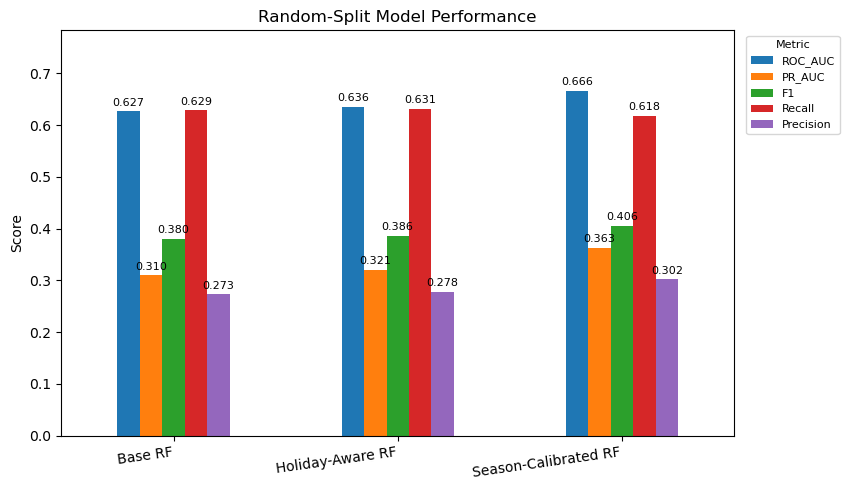

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Base RF,0.5660,0.2730,0.6290,0.3800,0.6270,0.3100
1,Holiday-Aware RF,0.5740,0.2780,0.6310,0.3860,0.6360,0.3210
2,Season-Calibrated RF,0.6170,0.3020,0.6180,0.4060,0.6660,0.3630


In [26]:
fig, ax = plt.subplots(figsize=(10.5, 5))
model_comparison.set_index("Model")[["ROC_AUC", "PR_AUC", "F1", "Recall", "Precision"]].plot(kind="bar", ax=ax)

ax.set_title("Random-Split Model Performance")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=8, ha="right")

add_bar_labels(ax, fmt="{:.3f}", padding=0.01)

ax.legend(
    title="Metric",
    fontsize=8,
    title_fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

model_comparison


### Model comparison interpretation

The random-split comparison shows that period and season context contain real signal, but this chart is a diagnostic step rather than the final proof of operational value.

The **Season-Calibrated RF** performed best in the random split, with ROC AUC around **0.666** and PR AUC around **0.363**, compared with **0.627 / 0.310** for the base model. That lift means the model is picking up meaningful structure from holiday timing and broader seasonal regime.

The caveat is methodological: in a random split, all three seasons can appear in both training and test data. That makes the season-calibrated result useful for explaining historical variation, but it is not the strongest test of forward performance.

The stronger question is answered next: can a model trained on prior holiday/winter seasons still rank risk in the latest season? That holdout result carries more weight for a staffing or operations use case.

Model performance was evaluated using ROC AUC and PR AUC. ROC AUC measures general ranking ability across disrupted and non-disrupted flights, while PR AUC focuses more directly on the disrupted-flight class. The best random-split model, the Season-Calibrated RF, improved ROC AUC to 0.666 and PR AUC to 0.363, compared with 0.627 and 0.310 for the Base RF. Because the overall disruption rate was about 21.2%, the PR AUC improvement indicates useful risk concentration, but not enough to treat the model as an automated decision system. The model is best used as an operations prioritization screen.


## 12. Lift Table Function

Operations teams rarely need a generic 0.50 threshold. The better question is whether the model concentrates disruption risk into a smaller subset of flights that deserve more attention.

The lift table evaluates top-scored risk buckets against the overall disruption baseline.

In [27]:
def lift_table(y_true, scores, quantiles=(0.05, 0.10, 0.20, 0.30)):
    out = []
    y_true = pd.Series(y_true).reset_index(drop=True)
    scores = pd.Series(scores).reset_index(drop=True)
    baseline = y_true.mean()

    temp = pd.DataFrame({"actual": y_true, "score": scores})
    temp = temp.sort_values("score", ascending=False).reset_index(drop=True)

    for q in quantiles:
        n = max(1, int(len(temp) * q))
        top = temp.head(n)
        rate = top["actual"].mean()
        captured = top["actual"].sum()
        total_disruptions = temp["actual"].sum()

        out.append({
            "Flagged Share": f"Top {int(q * 100)}%",
            "Flagged Flights": n,
            "Disruption Rate in Flagged Group": rate,
            "Baseline Disruption Rate": baseline,
            "Lift vs Baseline": rate / baseline if baseline else np.nan,
            "Captured Disruptions": captured,
            "Share of All Disruptions Captured": captured / total_disruptions if total_disruptions else np.nan,
        })

    return pd.DataFrame(out)


random_split_lift = lift_table(y_test.reset_index(drop=True), holiday_proba)
display_export(random_split_lift, "random_split_lift_table.csv")


Saved outputs\random_split_lift_table.csv


,Flagged Share,Flagged Flights,Disruption Rate in Flagged Group,Baseline Disruption Rate,Lift vs Baseline,Captured Disruptions,Share of All Disruptions Captured
0,Top 5%,3750,0.4381,0.2121,2.0659,1643,0.1033
1,Top 10%,7500,0.3863,0.2121,1.8213,2897,0.1821
2,Top 20%,15000,0.3386,0.2121,1.5966,5079,0.3193
3,Top 30%,22500,0.3118,0.2121,1.4701,7015,0.4410


## 13. Temporal Validation: Train Prior Seasons, Test Latest Season

This is the most important validation test in the notebook.

The model is trained on the **2023–2024** and **2024–2025** seasons and tested on the unseen **2025–2026** season.

This answers the operational question more directly than a random split:

> Can prior holiday/winter operating history identify risk concentration in a later holiday/winter season?


In [28]:
temporal_df = work.copy()
train_temporal = temporal_df[temporal_df["season"].astype(str).ne(latest_season)].copy()
test_temporal = temporal_df[temporal_df["season"].astype(str).eq(latest_season)].copy()

print("Temporal training seasons:", sorted(train_temporal["season"].astype(str).unique().tolist()))
print("Temporal test season:", latest_season)
print("Temporal train rows:", f"{len(train_temporal):,}")
print("Temporal test rows:", f"{len(test_temporal):,}")

train_temporal_sample = stratified_sample(train_temporal, "disrupted", TRAIN_SAMPLE_N, random_state=RANDOM_STATE)

X_train_time = train_temporal_sample[holiday_features].copy()
y_train_time = train_temporal_sample["disrupted"].copy()
X_test_time = test_temporal[holiday_features].copy()
y_test_time = test_temporal["disrupted"].copy()

temporal_rf, _, _ = build_model(holiday_features)
temporal_metrics, temporal_pred, temporal_proba, temporal_rf = evaluate_model(
    temporal_rf,
    X_train_time,
    X_test_time,
    y_train_time,
    y_test_time,
    "Holiday-Aware RF | Prior Seasons → Latest Season",
)

temporal_metrics_df = pd.DataFrame([temporal_metrics]).round(3)
display_export(temporal_metrics_df, "temporal_holdout_metrics.csv")


Temporal training seasons: ['2023-2024', '2024-2025']
Temporal test season: 2025-2026
Temporal train rows: 3,387,174
Temporal test rows: 1,696,857


Saved outputs\temporal_holdout_metrics.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Holiday-Aware RF | Prior Seasons → Latest Season,0.5650,0.3040,0.5630,0.3950,0.5910,0.3170


In [29]:
temporal_lift = lift_table(y_test_time.reset_index(drop=True), temporal_proba)
display_export(temporal_lift, "temporal_holdout_lift_table.csv")


Saved outputs\temporal_holdout_lift_table.csv


,Flagged Share,Flagged Flights,Disruption Rate in Flagged Group,Baseline Disruption Rate,Lift vs Baseline,Captured Disruptions,Share of All Disruptions Captured
0,Top 5%,84842,0.3680,0.2517,1.4616,31218,0.0731
1,Top 10%,169685,0.3367,0.2517,1.3375,57136,0.1338
2,Top 20%,339371,0.3288,0.2517,1.3061,111585,0.2612
3,Top 30%,509057,0.3214,0.2517,1.2765,163589,0.3830


### Temporal holdout interpretation

The prior-season holdout is the key validation result. It trains on **2023–2024** and **2024–2025**, then tests on the unseen **2025–2026** season.

Performance falls versus the random split, which is expected and analytically important. The random split measures ranking ability inside a mixed historical sample. The temporal holdout measures forward transfer into a later operating regime.

The lift table still shows usable separation. In the latest-season holdout, the **top 10% highest-scored flights disrupted at about 33.7%**, versus a latest-season baseline of about **25.2%**. That is about **1.34x baseline risk**. The top 30% captured about **38.3% of all latest-season disruptions** while covering 30% of flights.

That is not strong enough to automate staffing decisions, but it is strong enough to support risk triage. In practice, the value is not that the model “predicts disruption” in a deterministic sense. The value is that it ranks the schedule into more and less disruption-dense groups before outcomes are known.

The weaker holdout lift also clarifies the boundary of public schedule data. Schedule, carrier, route, airport, holiday window, and time-block features capture structural exposure. They do not capture the full shock layer: weather, aircraft rotations, crew legality, gate availability, maintenance, passenger loads, or real-time recovery decisions.


## 14. January Holdout: Train Prior History + Latest Nov/Dec, Test Latest January

This validation approximates a rolling planning use case.

Training data:

- all rows from `2023-2024` and `2024-2025`
- plus November and December rows from `2025-2026`

Test data:

- January rows from `2025-2026`

This answers:

> After observing the first two months of the current holiday/winter season, can the model rank risk in January?


In [30]:
latest_jan_mask = temporal_df["season"].astype(str).eq(latest_season) & temporal_df["Month"].eq(1)
latest_nov_dec_mask = temporal_df["season"].astype(str).eq(latest_season) & temporal_df["Month"].isin([11, 12])
prior_seasons_mask = temporal_df["season"].astype(str).ne(latest_season)

train_jan_holdout = temporal_df[prior_seasons_mask | latest_nov_dec_mask].copy()
test_jan_holdout = temporal_df[latest_jan_mask].copy()

print("January holdout train rows:", f"{len(train_jan_holdout):,}")
print("January holdout test rows:", f"{len(test_jan_holdout):,}")

if len(test_jan_holdout) == 0:
    raise ValueError("No latest-season January rows found for January holdout validation.")

train_jan_sample = stratified_sample(train_jan_holdout, "disrupted", TRAIN_SAMPLE_N, random_state=RANDOM_STATE)

X_train_jan = train_jan_sample[holiday_features].copy()
y_train_jan = train_jan_sample["disrupted"].copy()
X_test_jan = test_jan_holdout[holiday_features].copy()
y_test_jan = test_jan_holdout["disrupted"].copy()

jan_rf, _, _ = build_model(holiday_features)
jan_metrics, jan_pred, jan_proba, jan_rf = evaluate_model(
    jan_rf,
    X_train_jan,
    X_test_jan,
    y_train_jan,
    y_test_jan,
    "Holiday-Aware RF | Prior History + Latest Nov/Dec → Latest Jan",
)

jan_metrics_df = pd.DataFrame([jan_metrics]).round(3)
display_export(jan_metrics_df, "january_holdout_metrics.csv")


January holdout train rows: 4,540,028
January holdout test rows: 544,003


Saved outputs\january_holdout_metrics.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Holiday-Aware RF | Prior History + Latest Nov/...,0.4780,0.2720,0.6650,0.3860,0.5590,0.2860


In [31]:
jan_lift = lift_table(y_test_jan.reset_index(drop=True), jan_proba)
display_export(jan_lift, "january_holdout_lift_table.csv")


Saved outputs\january_holdout_lift_table.csv


,Flagged Share,Flagged Flights,Disruption Rate in Flagged Group,Baseline Disruption Rate,Lift vs Baseline,Captured Disruptions,Share of All Disruptions Captured
0,Top 5%,27200,0.3311,0.2468,1.3418,9007,0.0671
1,Top 10%,54400,0.3026,0.2468,1.2260,16460,0.1226
2,Top 20%,108800,0.2884,0.2468,1.1687,31380,0.2337
3,Top 30%,163200,0.2878,0.2468,1.1663,46975,0.3499


### January holdout interpretation

The January holdout is the hardest test because January disruption can be dominated by acute winter events and cancellation spikes. Those events are only partially visible from public schedule features.

The lift is positive but modest. The **top 10% highest-scored January flights disrupted at about 30.3%**, compared with a January baseline of about **24.7%**. That is about **1.23x baseline risk**. The top 5% performed better at about **33.1%**, or **1.34x baseline risk**.

This result should be interpreted carefully. The model still ranks some January risk, but January-specific disruption is harder to anticipate without live operational inputs. For a production workflow, the schedule-based score would be a first-pass screen that gets updated with weather, aircraft rotation, crew, station, gate, and recovery signals.


## 15. Staffing-Window Recommendation Layer

This section converts flight-level model scores into date / airport / departure-window recommendations.

The model is not treated as an automated staffing system. It is used as a risk-screening tool to prioritize operating windows that may justify extra monitoring, customer support readiness, or on-call coverage.

For portfolio purposes, the most defensible recommendation layer uses holdout predictions, not in-sample predictions.

In [32]:
# Use the full latest-season temporal holdout scores for staffing-window aggregation.
scored_latest = test_temporal[[
    "FlightDate",
    "season",
    "analysis_period",
    "Origin",
    "Dest",
    "DepTimeBlk",
    "ArrTimeBlk",
    "disrupted",
    "delay15_flag",
    "cancel_flag",
    "divert_flag",
]].copy()

scored_latest["risk_score"] = temporal_proba

# Risk scores from the class-weighted Random Forest are used for ranking.
# They should not be interpreted as calibrated disruption probabilities.
scored_latest["risk_score_sum"] = scored_latest["risk_score"]

# Focus recommendation layer on the defined holiday/baseline operating windows.
staffing_source = scored_latest[scored_latest["analysis_period"].isin(PERIOD_ORDER)].copy()

risk_q90 = staffing_source["risk_score"].quantile(0.90)
risk_q75 = staffing_source["risk_score"].quantile(0.75)

staffing_windows = (
    staffing_source.groupby(["season", "FlightDate", "analysis_period", "Origin", "DepTimeBlk"], observed=True)
    .agg(
        flights=("disrupted", "size"),
        avg_risk_score=("risk_score", "mean"),
        risk_score_sum=("risk_score_sum", "sum"),
        actual_disruption_rate=("disrupted", "mean"),
        actual_delay15_rate=("delay15_flag", "mean"),
        actual_cancellation_rate=("cancel_flag", "mean"),
    )
    .reset_index()
)

staffing_windows = staffing_windows[staffing_windows["flights"] >= MIN_STAFFING_WINDOW_FLIGHTS].copy()

conditions = [
    staffing_windows["avg_risk_score"] >= risk_q90,
    staffing_windows["avg_risk_score"] >= risk_q75,
]
choices = ["Extra on-call coverage", "Monitor closely"]
staffing_windows["recommendation"] = np.select(conditions, choices, default="Normal coverage")

for col in ["avg_risk_score", "actual_disruption_rate", "actual_delay15_rate", "actual_cancellation_rate"]:
    staffing_windows[col + "_pct"] = staffing_windows[col] * 100

staffing_windows = staffing_windows.sort_values(
    ["avg_risk_score", "risk_score_sum", "flights"],
    ascending=False,
)

_ = display_export(staffing_windows, "staffing_recommendations.csv")
print(f"Staffing windows exported: {len(staffing_windows):,}")
print("Risk score thresholds:")
print(f" - 75th percentile: {risk_q75:.3f}")
print(f" - 90th percentile: {risk_q90:.3f}")


Saved outputs\staffing_recommendations.csv
Staffing windows exported: 6,872
Risk score thresholds:
 - 75th percentile: 0.563
 - 90th percentile: 0.597


In [33]:
top_staffing_windows = staffing_windows.head(10)[[
    "season",
    "FlightDate",
    "analysis_period",
    "Origin",
    "DepTimeBlk",
    "flights",
    "avg_risk_score_pct",
    "risk_score_sum",
    "actual_disruption_rate_pct",
    "actual_cancellation_rate_pct",
    "recommendation",
]]

top_staffing_windows


,season,FlightDate,analysis_period,Origin,DepTimeBlk,flights,avg_risk_score_pct,risk_score_sum,actual_disruption_rate_pct,actual_cancellation_rate_pct,recommendation
39875,2025-2026,2025-12-27,Christmas Week,FLL,2000-2059,33,70.4697,23.2550,96.9697,9.0909,Extra on-call coverage
42741,2025-2026,2025-12-28,Christmas Week,FLL,2000-2059,34,69.7797,23.7251,88.2353,2.9412,Extra on-call coverage
36970,2025-2026,2025-12-26,Christmas Week,FLL,2000-2059,32,68.5183,21.9259,93.7500,28.1250,Extra on-call coverage
43428,2025-2026,2025-12-28,Christmas Week,MCO,2000-2059,32,68.2494,21.8398,71.8750,0.0000,Extra on-call coverage
43429,2025-2026,2025-12-28,Christmas Week,MCO,2100-2159,25,67.9348,16.9837,80.0000,0.0000,Extra on-call coverage
39873,2025-2026,2025-12-27,Christmas Week,FLL,1800-1859,26,67.6343,17.5849,92.3077,11.5385,Extra on-call coverage
23312,2025-2026,2025-12-21,Christmas Week,FLL,2000-2059,34,67.6327,22.9951,58.8235,2.9412,Extra on-call coverage
39664,2025-2026,2025-12-27,Christmas Week,DFW,2000-2059,53,67.5580,35.8057,32.0755,0.0000,Extra on-call coverage
40661,2025-2026,2025-12-27,Christmas Week,MIA,2000-2059,25,67.5185,16.8796,68.0000,0.0000,Extra on-call coverage
39479,2025-2026,2025-12-27,Christmas Week,CLT,2000-2059,46,67.2686,30.9435,36.9565,0.0000,Extra on-call coverage


In [34]:
def weighted_avg(group, value_col, weight_col="flights"):
    return np.average(group[value_col], weights=group[weight_col]) if group[weight_col].sum() else np.nan

recommendation_distribution = (
    staffing_windows.groupby("recommendation", observed=True)
    .apply(lambda g: pd.Series({
        "windows": len(g),
        "flights": g["flights"].sum(),
        "avg_risk_score": weighted_avg(g, "avg_risk_score"),
        "actual_disruption_rate": weighted_avg(g, "actual_disruption_rate"),
        "actual_delay15_rate": weighted_avg(g, "actual_delay15_rate"),
        "actual_cancellation_rate": weighted_avg(g, "actual_cancellation_rate"),
    }))
    .reset_index()
)

recommendation_order = ["Extra on-call coverage", "Monitor closely", "Normal coverage"]
recommendation_distribution["recommendation"] = pd.Categorical(
    recommendation_distribution["recommendation"],
    categories=recommendation_order,
    ordered=True,
)
recommendation_distribution = recommendation_distribution.sort_values("recommendation")

for col in ["avg_risk_score", "actual_disruption_rate", "actual_delay15_rate", "actual_cancellation_rate"]:
    recommendation_distribution[col + "_pct"] = recommendation_distribution[col] * 100

display_export(recommendation_distribution, "staffing_recommendation_distribution.csv")


Saved outputs\staffing_recommendation_distribution.csv


,recommendation,windows,flights,avg_risk_score,actual_disruption_rate,actual_delay15_rate,actual_cancellation_rate,avg_risk_score_pct,actual_disruption_rate_pct,actual_delay15_rate_pct,actual_cancellation_rate_pct
0,Extra on-call coverage,610.0000,"23,938.0000",0.6220,0.3875,0.3620,0.0224,62.2012,38.7459,36.2019,2.2391
1,Monitor closely,"1,071.0000","42,346.0000",0.5784,0.3561,0.2977,0.0554,57.8415,35.6067,29.7714,5.5377
2,Normal coverage,"5,191.0000","201,047.0000",0.4923,0.2730,0.2289,0.0415,49.2317,27.3016,22.8932,4.1538


### Staffing-window interpretation

The staffing layer converts flight-level scores into date / origin airport / departure-block windows for the latest season.

Because the Random Forest uses class weighting, the score is a **relative risk score**, not a calibrated disruption probability. The recommendation logic therefore uses score percentiles to separate normal coverage, closer monitoring, and extra on-call coverage candidates.

The group-level results show useful separation. **Extra on-call coverage** windows had a weighted realized disruption rate of about **38.7%**, versus **35.6%** for monitor windows and **27.3%** for normal-coverage windows. That ordering matters more than the exact score values.

The top-window table is intentionally small. Its purpose is not to claim that every listed window requires staffing action. Its purpose is to identify the windows where an operations team would have the strongest case to review coverage, communication readiness, and escalation capacity before disruption is realized.


## 16. Final Findings and Portfolio Summary

### Final findings

The three-season design makes the analysis stronger because it compares the same holiday/winter operating window across matched annual periods. That helps separate recurring seasonal pressure from single-season event noise.

The descriptive results show that risk is not uniform across holiday windows. Across all three seasons, **Christmas Week** had the highest overall disruption rate at about **25.4%**. The **January 15–30 baseline** was close behind at about **24.3%**, but its disruption mix was different: January carried a much larger cancellation component. That distinction matters because delay-heavy and cancellation-heavy periods create different operating workloads.

The time-block analysis is the clearest operational pattern. Disruption risk generally increases later in the day, especially in high-stress holiday/winter windows. In the latest season, late-day disruption reached about **36.0% during Christmas Week** and **40.4% during New Year's Week**.

The modeling results are useful but should be framed precisely. Holiday and season context improved random-split performance, but the holdout tests are more realistic. In the prior-season-to-latest-season holdout, the top 10% highest-scored flights disrupted at about **33.7%** versus a latest-season baseline of about **25.2%**. In the January holdout, the top 10% disrupted at about **30.3%** versus a January baseline of about **24.7%**.

The staffing layer translates that ranking value into an operations view. Extra on-call coverage windows had higher realized disruption than monitor and normal-coverage windows, which supports the model's use as a triage screen.

The conclusion is:

> Scheduled flight characteristics, holiday-window context, and departure-time patterns can support disruption risk screening and operational prioritization. The model is not a staffing automation engine; it is a structured way to identify where monitoring, communication readiness, and on-call escalation are most defensible.

### Limitations

This analysis uses public BTS / DOT schedule and outcome data. It does not include real-time weather, aircraft rotation, crew legality, gate constraints, maintenance status, passenger loads, airport staffing, or live recovery decisions. Those missing inputs explain why holdout performance is weaker than random-split performance and would be required for production deployment.

### Portfolio summary

Built a three-season BTS/DOT flight disruption risk-screening workflow using November–January airline operations data across the 2023–2024, 2024–2025, and 2025–2026 holiday/winter seasons. Engineered holiday-window, time-block, route, airport, and carrier features; compared base, holiday-aware, and season-calibrated Random Forest models; validated forward ranking performance through prior-season and January holdouts; and translated flight-level risk scores into date / airport / departure-window recommendations for operational monitoring and extra on-call coverage prioritization.
